## Постановка задачи

Имеется краевая задача:

$$
\begin{cases}
-u''(x) = f(x), \quad x \in (0, 1) \\[0.5em]
u(0) = 0 \\[0.5em]
u(1) = 0
\end{cases}
$$

где функция $f(x)$ имеет разрыв:

$$
f(x) = 
\begin{cases}
x, & x \leq 0.5 \\
0.5, & x > 0.5
\end{cases}
$$

## Точное решение

Точное решение $u(x)$ имеет вид:

$$
u(x) = 
\begin{cases}
-\dfrac{x^3}{6} + \dfrac{7}{48}, & x \leq 0.5 \\[1em]
-\dfrac{x^2}{4} + \dfrac{x}{8} + \dfrac{1}{8}, & x > 0.5
\end{cases}
$$

## Численная схема

### 1. Дискретизация области

Разобьём отрезок $[0, 1]$ на $N$ частей:

$$
h = \frac{1}{N}, \quad x_i = ih, \quad i = 0, 1, \dots, N
$$

### 2. Конечно-разностная аппроксимация

Заменим вторую производную центральной разностью:

$$
-u''(x_i) \approx -\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} = f(x_i)
$$

где $u_i \approx u(x_i)$.

### 3. Система уравнений

Для внутренних точек $i = 1, 2, \dots, N-1$:

$$
-\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2} = f_i
$$

Граничные условия:
- Условие Неймана: $u'(0) = 0 \Rightarrow u_0 = u_1$
- Условие Дирихле: $u_N = 0$

Получаем систему $(N-1)$ уравнений:

$$
\mathbf{A}\mathbf{u} = -\mathbf{f}
$$

где матрица $\mathbf{A}$ трёхдиагональная:

$$
A_{ii} = -\frac{2}{h^2}, \quad A_{i,i-1} = A_{i,i+1} = \frac{1}{h^2}
$$

с поправкой для граничного условия:
$$
A_{11} = -\frac{2}{h^2} + \frac{1}{h^2} = -\frac{1}{h^2}
$$

## Обратная задача (регуляризация)

### 1. Вычисление $f_m$

Из численного решения $u_i$ восстанавливаем правую часть:

$$
f_m^{(i)} = -\frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}, \quad i = 1, 2, \dots, N-1
$$

### 2. Постановка обратной задачи

Имеем операторное уравнение:

$$
Kf = f_m
$$

где $K$ - интегральный оператор, соответствующий решению задачи $-u'' = f$.

### 3. Метод Тихонова

Минимизируем функционал:

$$
J_\alpha[f] = \|Kf - f_m\|^2_{L_2} + \alpha \|Lf\|^2_{L_2}
$$

где $\alpha > 0$ - параметр регуляризации, $L = \frac{d^2}{dx^2}$ - оператор регуляризации.

### 4. Дискретная регуляризация

Используем регуляризацию вида $(I + \sqrt{\alpha}D)^2$, где $D$ - дискретный аналог второй производной:

$$
(I + \sqrt{\alpha}D)^2 f = f_m
$$

где $D$ - матрица размера $(N-1) \times (N-1)$:

$$
D_{ii} = -\frac{2}{h^2}, \quad D_{i,i-1} = D_{i,i+1} = \frac{1}{h^2}
$$

### 5. Решение регуляризованной системы

Решаем систему линейных уравнений:

$$
\mathbf{A}_\alpha \mathbf{f}_{reg} = \mathbf{f}_m
$$

где $\mathbf{A}_\alpha = (I + \sqrt{\alpha}D)^2$

## Алгоритм

1. **Прямая задача**:
   - Задать сетку $\{x_i\}_{i=0}^N$
   - Вычислить $\mathbf{f} = [f(x_1), f(x_2), \dots, f(x_{N-1})]^T$
   - Решить $\mathbf{A}\mathbf{u} = -\mathbf{f}$
   - Добавить граничные условия

2. **Обратная задача**:
   - Вычислить $\mathbf{f}_m = -D\mathbf{u}_{inner}$
   - Построить матрицу регуляризации $\mathbf{A}_\alpha$
   - Решить $\mathbf{A}_\alpha\mathbf{f}_{reg} = \mathbf{f}_m$

3. **Визуализация**:
   - Сравнить точное и численное решения $u(x)$
   - Сравнить точное, вычисленное и регуляризованное $f(x)$

## Особенности реализации

- Разрывная $f(x)$ приводит к потере гладкости решения
- Регуляризация сглаживает восстанавливаемую функцию
- Параметр $\alpha$ контролирует баланс между точностью и устойчивостью

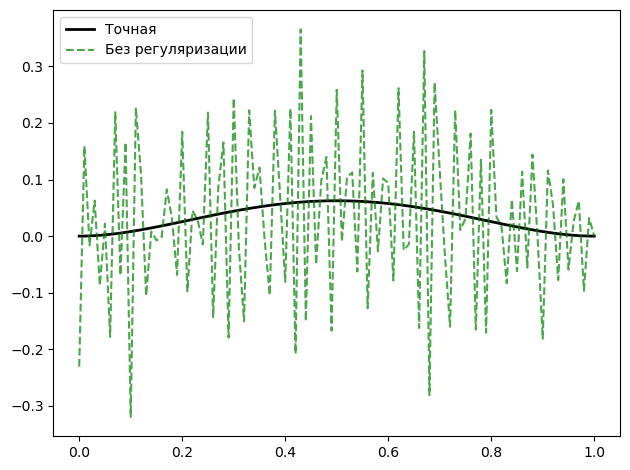

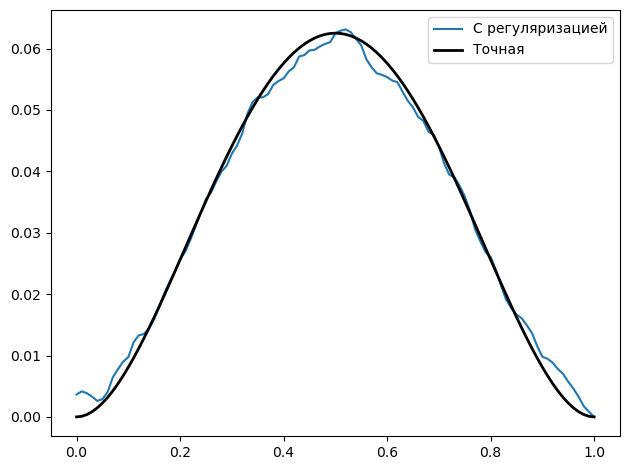

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def u_analytic(x):
    # return -np.piecewise(x, [x <= 0.5, x > 0.5], 
    #                     [lambda x: x**3/6 - 7/48, lambda x: x**2/4 - x/8 - 1/8])
    return -x**6 / 30 + x**5 / 10 - x**4 / 12 

def f_exact(x):
    # return np.piecewise(x, [x <= 0.5, x > 0.5], [lambda x: x, 0.5])
    # return np.sin(np.pi*x)*(x - x*x)
    return x**4 - 2*x**3 + x**2

def find_f(h, u, alpha=0, delta=0, seed=42):
    x = np.arange(0, 1 + h, h)
    N = len(x) - 1
    
    if delta > 0:
        np.random.seed(seed)
        u = u + np.random.uniform(-delta, delta, len(x))
    
    D = np.zeros((N+1, N+1))
    for i in range(1, N):
        D[i, i-1:i+2] = [1/h**2, -2/h**2, 1/h**2]
    D[0, :2] = [-2/h**2, 2/h**2]  # u'(0)=0
    D[-1, -1] = 1  
    

    L = np.eye(N+1) - np.sqrt(alpha) * D
    b = -D @ u
    b[-1] = 0
    y = np.linalg.solve(L, b)
    f_recovery = np.linalg.solve(L, y)
    
    return f_recovery


    
n=100
delta = 1e-5
alpha=6.020894493336126e-07
# best_alpha

h = 1.0 / n
x = np.arange(0, 1 + h, h)
u_acc = u_analytic(x)
f = find_f(h, u_acc, alpha, delta)
f_no_reg = find_f(h, u_acc, 0, delta)
f_no_noise = find_f(h, u_acc, 0, 0)

err = np.sqrt(np.sum((f - f_exact(x))**2) * h)
plt.plot(x, f_exact(x), 'k-', linewidth=2, label='Точная')
plt.plot(x, f_no_reg, 'g--', linewidth=1.5, alpha=0.7, label='Без регуляризации')
# plt.plot(x, f_no_noise, 'r--', linewidth=1.5, alpha=0.7, label='Без регуляризации')

plt.legend()
plt.tight_layout()
plt.show()
        

plt.plot(x,f,label='C регуляризацией')
plt.plot(x, f_exact(x), 'k-', linewidth=2, label='Точная')
plt.legend()
plt.tight_layout()
plt.show()



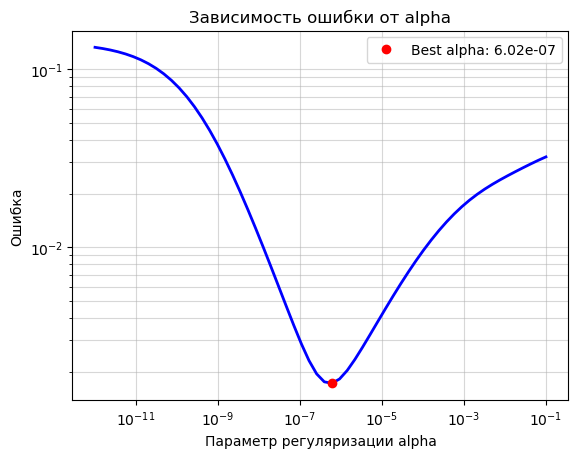

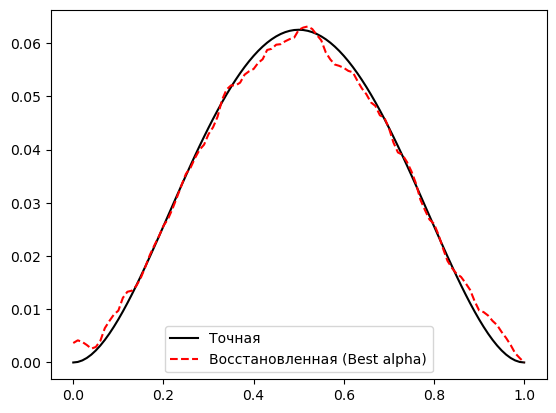

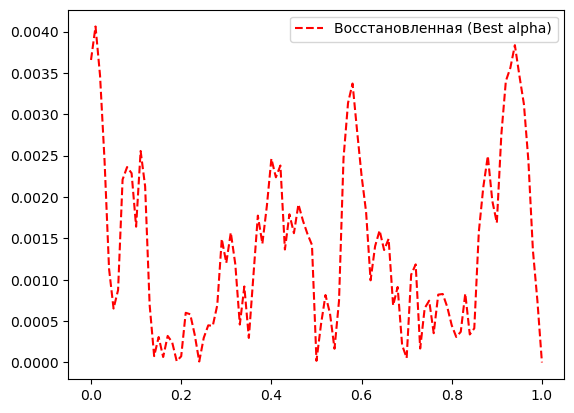

In [3]:
alphas = np.logspace(-12, -1, 60)
errors = []

for a in alphas:
    f_curr = find_f(h, u_acc, a, delta)
    err_curr = np.sqrt(np.sum((f_curr - f_exact(x))**2) * h)
    errors.append(err_curr)

idx_min = np.argmin(errors)
best_alpha = alphas[idx_min]

plt.figure()
plt.loglog(alphas, errors, 'b-', linewidth=2)
plt.plot(best_alpha, errors[idx_min], 'ro', label=f'Best alpha: {best_alpha:.2e}')
plt.xlabel('Параметр регуляризации alpha')
plt.ylabel('Ошибка')
plt.title('Зависимость ошибки от alpha')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

f_best = find_f(h, u_acc, best_alpha, delta)
plt.figure()
plt.plot(x, f_exact(x), 'k-', label='Точная')
plt.plot(x, f_best, 'r--', label='Восстановленная (Best alpha)')
plt.legend()
plt.show()

f_best = find_f(h, u_acc, best_alpha, delta)
plt.figure()
plt.plot(x, np.abs(f_exact(x) - f_best), 'r--', label='Восстановленная (Best alpha)')
plt.legend()
plt.show()

In [9]:
best_alpha

np.float64(6.020894493336126e-07)